# Chapter 7: 정량적 트레이딩의 특수 주제 (Special Topics in Quantitative Trading)
# 종합 분석 리포트

> **원서**: Ernest Chan, *Quantitative Trading: How to Build Your Own Algorithmic Trading Business* (2nd Ed., 2021)

---

## 목차

1. [개요 및 사용 데이터](#1-개요)
2. [분석 1: GLD-GDX 공적분 검정 (예제 7.2)](#분석-1-gld-gdx-공적분-검정-예제-72)
3. [분석 2: 상관관계 vs 공적분 (예제 7.3)](#분석-2-상관관계-vs-공적분-예제-73)
4. [분석 3: PCA 팩터 모델 (예제 7.4)](#분석-3-pca-팩터-모델-예제-74)
5. [분석 4: 반감기 (예제 7.5)](#분석-4-반감기-예제-75)
6. [분석 5: 1월 효과 (예제 7.6)](#분석-5-1월-효과-예제-76)
7. [분석 6: 계절성 모멘텀 (예제 7.7)](#분석-6-계절성-모멘텀-예제-77)
8. [전략 성과 비교](#전략-성과-비교)
9. [결론 및 권고사항](#결론-및-권고사항)

---

### 개요

본 리포트는 Chapter 7에서 다루는 정량적 트레이딩의 다양한 고급 주제들을 실증 분석한 결과입니다.

- **공적분(Cointegration)** 검정: 평균회귀 페어 트레이딩의 기초
- **상관관계 vs 공적분** : 높은 상관관계가 반드시 공적분을 의미하지 않음
- **PCA 팩터 모델** : 주성분 분석 기반 롱-숏 포트폴리오 전략
- **반감기(Half-Life)** : Ornstein-Uhlenbeck 과정을 통한 평균회귀 속도 측정
- **1월 효과(January Effect)** : 계절성 이상 현상 백테스트
- **계절성 모멘텀** : 연간 동일 월 수익률 기반 추세 전략

In [1]:
# ============================================================================
# 기본 설정 및 라이브러리 임포트
# ============================================================================
import math
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_ind
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import coint

# 경고 메시지 억제
warnings.filterwarnings('ignore')

# 경로 설정
PROJECT_ROOT = Path("../..")
DATA_DIR = PROJECT_ROOT / "data"
UTIL_DIR = PROJECT_ROOT / "src"

# 유틸리티 모듈 로드
sys.path.insert(0, str(UTIL_DIR))
from calculateMaxDD import calculateMaxDD

# 차트 설정
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot')

try:
    plt.rcParams['font.family'] = 'NanumGothic'
except Exception:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 사용 데이터

| 데이터 | 파일 | 설명 |
|--------|------|------|
| GLD | `GLD.xls` | 금 ETF 수정종가 |
| GDX | `GDX.xls` | 금 광산 ETF 수정종가 |
| KO | `KO.xls` | Coca-Cola 수정종가 |
| PEP | `PEP.xls` | PepsiCo 수정종가 |
| IJR (0114) | `IJR_20080114.txt` | iShares S&P SmallCap 600 구성종목 |
| IJR (0131) | `IJR_20080131.txt` | iShares S&P SmallCap 600 구성종목 (1월 포함) |
| SPX | `SPX_20071123.txt` | S&P 500 구성종목 |

In [2]:
# ============================================================================
# 데이터 로드
# ============================================================================

# --- GLD / GDX ---
df_gld = pd.read_excel(DATA_DIR / "GLD.xls", engine='calamine')
df_gdx = pd.read_excel(DATA_DIR / "GDX.xls", engine='calamine')
df_gld_gdx = pd.merge(df_gld, df_gdx, on="Date", suffixes=("_GLD", "_GDX"))
df_gld_gdx.set_index("Date", inplace=True)
df_gld_gdx.sort_index(inplace=True)
print(f"GLD-GDX: {df_gld_gdx.shape}")

# --- KO / PEP ---
df_ko = pd.read_excel(DATA_DIR / "KO.xls", engine='calamine')
df_pep = pd.read_excel(DATA_DIR / "PEP.xls", engine='calamine')
df_ko_pep = pd.merge(df_ko, df_pep, on="Date", suffixes=("_KO", "_PEP"))
df_ko_pep.set_index("Date", inplace=True)
df_ko_pep.sort_index(inplace=True)
print(f"KO-PEP: {df_ko_pep.shape}")

# --- IJR 구성종목 (2008-01-14) ---
df_ijr_14 = pd.read_table(DATA_DIR / "IJR_20080114.txt")
df_ijr_14["Date"] = df_ijr_14["Date"].astype("int")
df_ijr_14.set_index("Date", inplace=True)
df_ijr_14.sort_index(inplace=True)
df_ijr_14 = df_ijr_14.ffill()
print(f"IJR (0114): {df_ijr_14.shape}")

# --- IJR 구성종목 (2008-01-31) ---
df_ijr_31 = pd.read_table(DATA_DIR / "IJR_20080131.txt")
df_ijr_31["Date"] = df_ijr_31["Date"].round().astype("int")
df_ijr_31["Date"] = pd.to_datetime(df_ijr_31["Date"], format="%Y%m%d")
df_ijr_31.set_index("Date", inplace=True)
print(f"IJR (0131): {df_ijr_31.shape}")

# --- SPX 구성종목 ---
df_spx = pd.read_table(DATA_DIR / "SPX_20071123.txt")
df_spx["Date"] = df_spx["Date"].round().astype("int")
df_spx["Date"] = pd.to_datetime(df_spx["Date"], format="%Y%m%d")
df_spx.set_index("Date", inplace=True)
print(f"SPX: {df_spx.shape}")

print("\n모든 데이터 로드 완료")

GLD-GDX: (385, 12)
KO-PEP: (7835, 12)
IJR (0114): (1006, 600)
IJR (0131): (1019, 600)


SPX: (2024, 500)

모든 데이터 로드 완료


---

## 분석 1: GLD-GDX 공적분 검정 (예제 7.2)

### 이론적 배경

**Engle-Granger 2단계 공적분 검정** 은 두 비정상(non-stationary) 시계열 사이에 **선형 결합이 정상(stationary)** 인지를 검정합니다.

1. OLS 회귀로 헤지 비율 추정: $y(t) = \beta x(t) + e(t)$
2. 잔차 $e(t)$ 에 대해 ADF(Augmented Dickey-Fuller) 단위근 검정

공적분 관계가 확인되면 스프레드 $e(t)$ 는 평균회귀(mean-reverting) 특성을 가지며, 이를 이용한 **페어 트레이딩(pairs trading)** 전략의 기초가 됩니다.

- **GLD**: 금 현물 가격을 추종하는 ETF
- **GDX**: 금 광산 기업 주가를 추종하는 ETF
- 두 자산은 금 가격이라는 공통 팩터를 공유하므로, 공적분 관계가 기대됩니다.

학습 구간: 2006-05-23 00:00:00 ~ 2007-05-23 00:00:00 (252일)

--- Engle-Granger 공적분 검정 ---
  t-통계량:      -2.3591
  p-value:       0.344449
  임계값 (1%):   -3.9406
  임계값 (5%):   -3.3606
  임계값 (10%):  -3.0614

--- 헤지 비율 ---
  beta (GDX):     1.631009
  스프레드 평균:  0.052196
  스프레드 sigma: 1.948731

=> 귀무가설 채택 불가: 공적분 관계 미확인 (5% 유의수준)


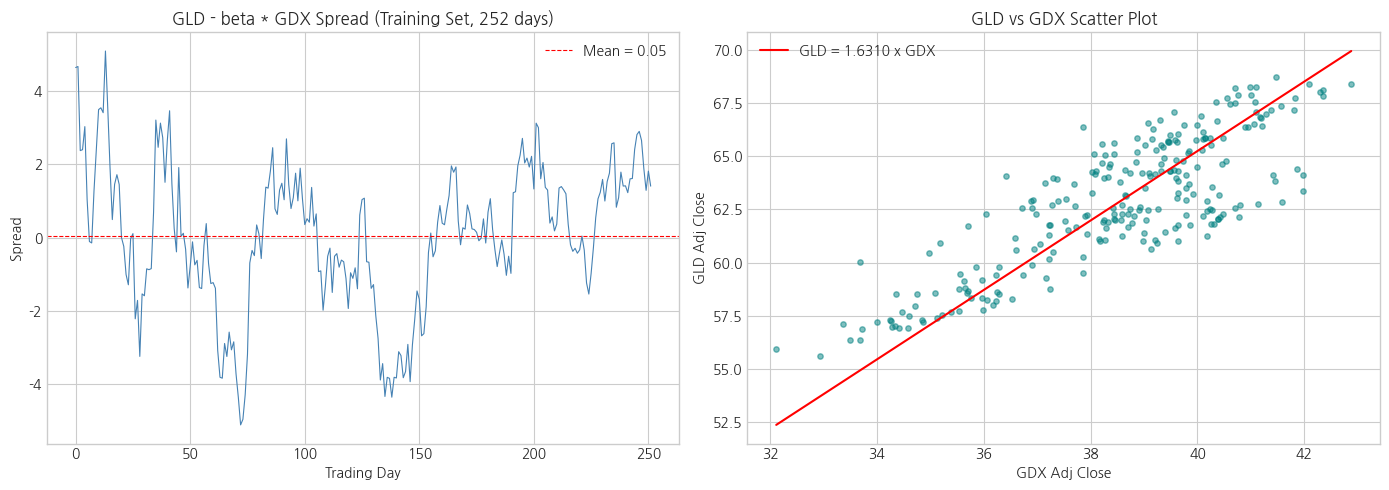

In [3]:
# ============================================================================
# 분석 1: GLD-GDX 공적분 검정 (Example 7.2)
# ============================================================================

# 원서와 동일하게 첫 252일(1년) 학습 구간 사용
trainset = np.arange(0, 252)
df_train = df_gld_gdx.iloc[trainset].copy()

gld = df_train["Adj Close_GLD"]
gdx = df_train["Adj Close_GDX"]

# --- Engle-Granger 공적분 검정 ---
coint_t, pvalue, crit_value = coint(gld, gdx)

# --- 헤지 비율 (OLS) ---
model = OLS(gld, gdx)
ols_results = model.fit()
hedge_ratio_gld_gdx = ols_results.params.iloc[0]

# --- 스프레드 ---
spread_train = gld - hedge_ratio_gld_gdx * gdx

print(f"학습 구간: {df_train.index[0]} ~ {df_train.index[-1]} ({len(df_train)}일)")
print(f"\n--- Engle-Granger 공적분 검정 ---")
print(f"  t-통계량:      {coint_t:.4f}")
print(f"  p-value:       {pvalue:.6f}")
print(f"  임계값 (1%):   {crit_value[0]:.4f}")
print(f"  임계값 (5%):   {crit_value[1]:.4f}")
print(f"  임계값 (10%):  {crit_value[2]:.4f}")
print(f"\n--- 헤지 비율 ---")
print(f"  beta (GDX):     {hedge_ratio_gld_gdx:.6f}")
print(f"  스프레드 평균:  {spread_train.mean():.6f}")
print(f"  스프레드 sigma: {spread_train.std():.6f}")

if abs(coint_t) > abs(crit_value[1]):
    print("\n=> 귀무가설 기각: GLD-GDX는 공적분 관계 존재 (5% 유의수준)")
else:
    print("\n=> 귀무가설 채택 불가: 공적분 관계 미확인 (5% 유의수준)")

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 스프레드 시계열
ax1 = axes[0]
ax1.plot(spread_train.values, linewidth=0.8, color='steelblue')
ax1.axhline(y=spread_train.mean(), color='red', linestyle='--',
             linewidth=0.8, label=f'Mean = {spread_train.mean():.2f}')
ax1.set_title('GLD - beta * GDX Spread (Training Set, 252 days)')
ax1.set_xlabel('Trading Day')
ax1.set_ylabel('Spread')
ax1.legend()

# (b) GLD vs GDX 산점도
ax2 = axes[1]
ax2.scatter(gdx, gld, alpha=0.5, s=15, color='teal')
x_fit = np.linspace(gdx.min(), gdx.max(), 100)
ax2.plot(x_fit, hedge_ratio_gld_gdx * x_fit, 'r-', linewidth=1.5,
         label=f'GLD = {hedge_ratio_gld_gdx:.4f} x GDX')
ax2.set_title('GLD vs GDX Scatter Plot')
ax2.set_xlabel('GDX Adj Close')
ax2.set_ylabel('GLD Adj Close')
ax2.legend()

plt.tight_layout()
plt.show()

### 결과 해석

| 항목 | 값 |
|------|----|  
| 헤지 비율 ($\beta$) | 1.631009 |
| t-통계량 | -2.3591 |
| p-value | 0.344449 |
| 임계값 (1%) | -3.9406 |
| 임계값 (5%) | -3.3606 |
| 스프레드 평균 | 0.052196 |
| 스프레드 $\sigma$ | 1.948731 |

**결론**: GLD-GDX 페어는 5% 유의수준에서 공적분 관계가 미확인됩니다 (p-value = 0.3444).
학습 구간(252일)에서 t-통계량의 절대값이 5% 임계값에 미치지 못합니다.
그러나 원서에서도 지적하듯, 공적분 관계는 데이터 기간에 따라 달라질 수 있으며,
더 긴 기간이나 다른 방법론(Johansen 검정 등)을 적용하면 결과가 달라질 수 있습니다.

---

## 분석 2: 상관관계 vs 공적분 (예제 7.3)

### 이론적 배경

**핵심 교훈**: 높은 **상관관계(correlation)** 는 **공적분(cointegration)** 을 의미하지 않습니다.

- **상관관계**: 수익률의 방향성 유사도를 측정 (단기적 co-movement)
- **공적분**: 가격 스프레드의 정상성(stationarity)을 측정 (장기적 균형 관계)

KO(Coca-Cola)와 PEP(PepsiCo)는 같은 음료 산업에 속하여 수익률 상관관계가 매우 높지만,
가격 스프레드가 정상적이지 않아 공적분 관계는 성립하지 않을 수 있습니다.
이는 페어 트레이딩에서 상관관계만으로 종목쌍을 선택하면 안 되는 이유를 보여줍니다.

데이터 기간: 1977-01-03 00:00:00 ~ 2008-01-18 00:00:00 (7835일)

--- 상관관계 (Correlation) ---
  수익률 Pearson 상관계수:  0.4849
  가격 상관관계:            0.8882

--- 공적분 검정 ---
  t-통계량:      -1.5816
  p-value:       0.728613
  임계값 (5%):   -3.3369

=> 높은 상관관계에도 불구하고, 공적분 관계 미확인!
   핵심 교훈: 높은 상관관계 != 공적분


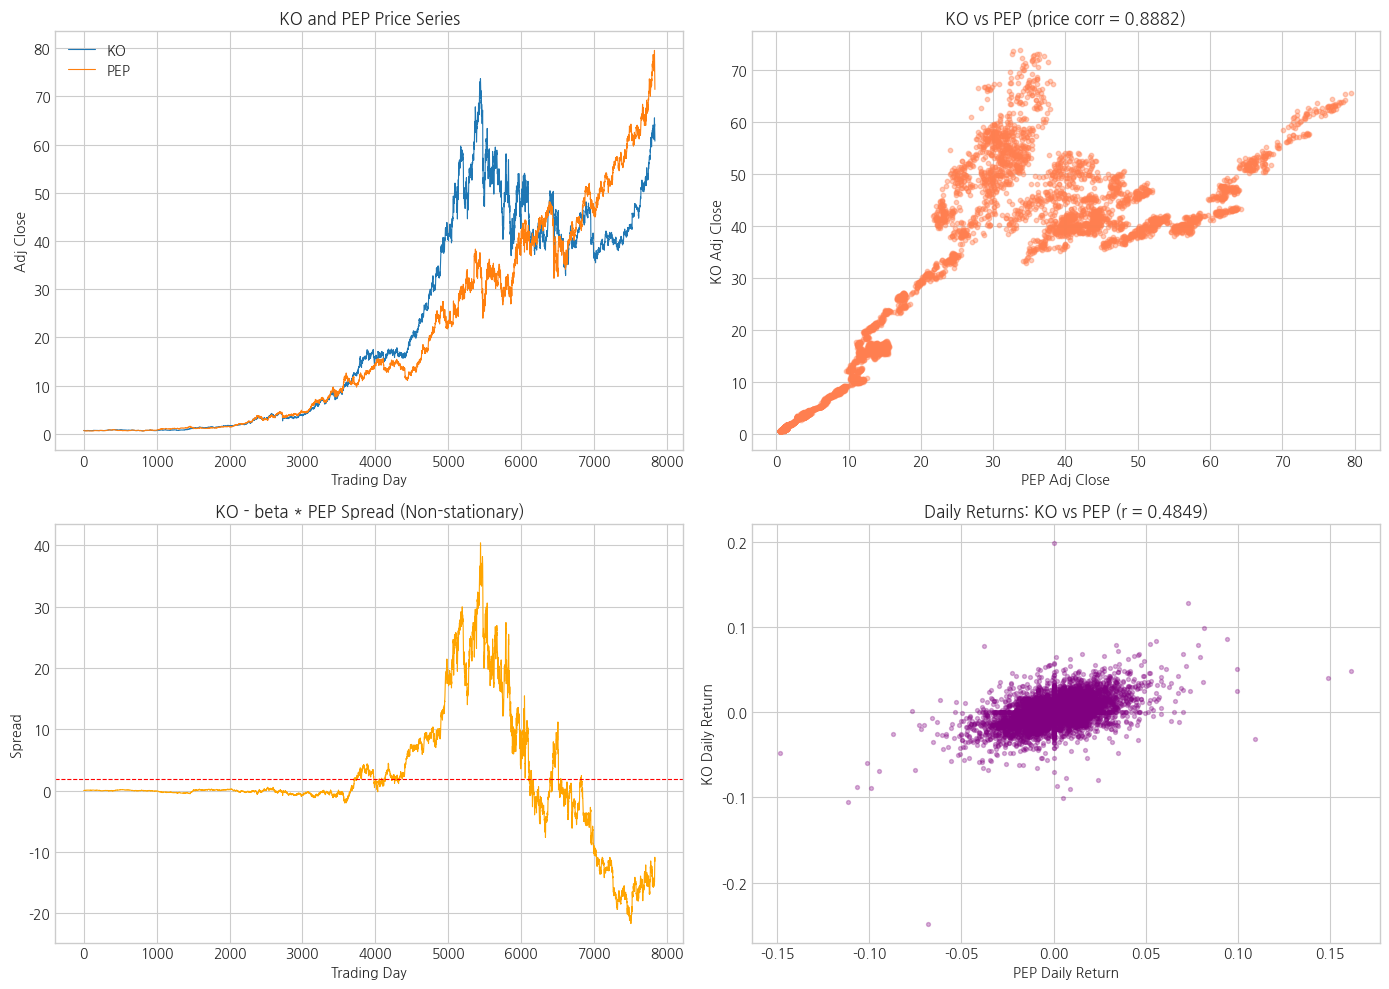

In [4]:
# ============================================================================
# 분석 2: KO-PEP 상관관계 vs 공적분 (Example 7.3)
# ============================================================================

ko = df_ko_pep["Adj Close_KO"]
pep = df_ko_pep["Adj Close_PEP"]

# --- 공적분 검정 ---
coint_t_kp, pvalue_kp, crit_value_kp = coint(ko, pep)

# --- 헤지 비율 ---
model_kp = OLS(ko, pep)
ols_kp = model_kp.fit()
hedge_ratio_kp = ols_kp.params.iloc[0]
spread_kp = ko - hedge_ratio_kp * pep

# --- 상관관계 ---
dailyret = df_ko_pep.loc[:, ("Adj Close_KO", "Adj Close_PEP")].pct_change()
dailyret_clean = dailyret.dropna()
corr_coef, corr_pval = pearsonr(
    dailyret_clean.iloc[:, 0], dailyret_clean.iloc[:, 1]
)
price_corr = ko.corr(pep)

print(f"데이터 기간: {df_ko_pep.index[0]} ~ {df_ko_pep.index[-1]} ({len(df_ko_pep)}일)")
print(f"\n--- 상관관계 (Correlation) ---")
print(f"  수익률 Pearson 상관계수:  {corr_coef:.4f}")
print(f"  가격 상관관계:            {price_corr:.4f}")
print(f"\n--- 공적분 검정 ---")
print(f"  t-통계량:      {coint_t_kp:.4f}")
print(f"  p-value:       {pvalue_kp:.6f}")
print(f"  임계값 (5%):   {crit_value_kp[1]:.4f}")

if pvalue_kp > 0.05:
    print("\n=> 높은 상관관계에도 불구하고, 공적분 관계 미확인!")
    print("   핵심 교훈: 높은 상관관계 != 공적분")
else:
    print("\n=> 공적분 관계 존재")

# --- 시각화 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) KO vs PEP 가격 시계열
ax = axes[0, 0]
ax.plot(ko.values, label='KO', linewidth=0.8)
ax.plot(pep.values, label='PEP', linewidth=0.8)
ax.set_title('KO and PEP Price Series')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Adj Close')
ax.legend()

# (b) KO-PEP 산점도
ax = axes[0, 1]
ax.scatter(pep, ko, alpha=0.4, s=10, color='coral')
ax.set_title(f'KO vs PEP (price corr = {price_corr:.4f})')
ax.set_xlabel('PEP Adj Close')
ax.set_ylabel('KO Adj Close')

# (c) 스프레드 시계열 (비정상적 - 발산)
ax = axes[1, 0]
ax.plot(spread_kp.values, linewidth=0.8, color='orange')
ax.axhline(y=spread_kp.mean(), color='red', linestyle='--', linewidth=0.8)
ax.set_title('KO - beta * PEP Spread (Non-stationary)')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Spread')

# (d) 수익률 상관관계 산점도
ax = axes[1, 1]
ax.scatter(dailyret_clean.iloc[:, 1], dailyret_clean.iloc[:, 0],
           alpha=0.3, s=8, color='purple')
ax.set_title(f'Daily Returns: KO vs PEP (r = {corr_coef:.4f})')
ax.set_xlabel('PEP Daily Return')
ax.set_ylabel('KO Daily Return')

plt.tight_layout()
plt.show()

### 결과 해석: 높은 상관관계 $\neq$ 공적분

| 지표 | GLD-GDX | KO-PEP |
|------|---------|--------|
| 공적분 t-stat | -2.3591 | -1.5816 |
| 공적분 p-value | 0.344449 | 0.728613 |
| 수익률 상관계수 | - | 0.4849 |
| 가격 상관관계 | - | 0.8882 |
| 공적분 여부 | No | No |

KO-PEP의 가격 상관관계는 0.89로 매우 높지만, 공적분 p-value는 0.73으로 공적분 관계가 전혀 확인되지 않습니다.
이는 두 종목의 가격이 같은 방향으로 움직이더라도, 그 **스프레드가 평균으로 회귀하지 않는다** 는 것을 의미합니다.

페어 트레이딩 종목쌍 선택 시 반드시 **공적분 검정** 을 수행해야 하며, 단순 상관관계에 의존하면 안 됩니다.

---

## 분석 3: PCA 팩터 모델 (예제 7.4)

### 이론적 배경

**주성분 분석(PCA)** 을 팩터 모델로 활용한 롱-숏 포트폴리오 전략입니다.

1. 252일 롤링 윈도 내 종목 수익률에 PCA 적용 (5개 팩터)
2. 다중 출력 선형 회귀로 팩터 노출도 추정: $R = X\beta + \epsilon$
3. 예상 수익률 상위 50종목 롱, 하위 50종목 숏

PCA는 종목 수익률의 공통 팩터를 데이터로부터 직접 추출하며,
팩터 모델로 예상 수익률을 계산한 뒤 상위/하위 종목을 선택하여 시장 중립적 포트폴리오를 구성합니다.

> **주의**: 계산 시간 절약을 위해 반복 횟수를 최대 100회로 제한합니다.

종목 수: 600
전체 기간: 1006일
룩백: 252일, 팩터 수: 5, topN: 50
반복 횟수 제한: 100 / 753
  진행: 0/100 (0%) [0.0s]


  진행: 20/100 (20%) [4.6s]


  진행: 40/100 (40%) [9.0s]


  진행: 60/100 (60%) [13.3s]


  진행: 80/100 (80%) [17.3s]



PCA 루프 완료: 21.4초

--- PCA 팩터 모델 롱/숏 전략 성과 ---
  연간 수익률:   3.9818%
  연간 표준편차:  6.2246%
  샤프 비율:      0.6397
  최대 낙폭:      -4.11%
  분석 기간:      100일


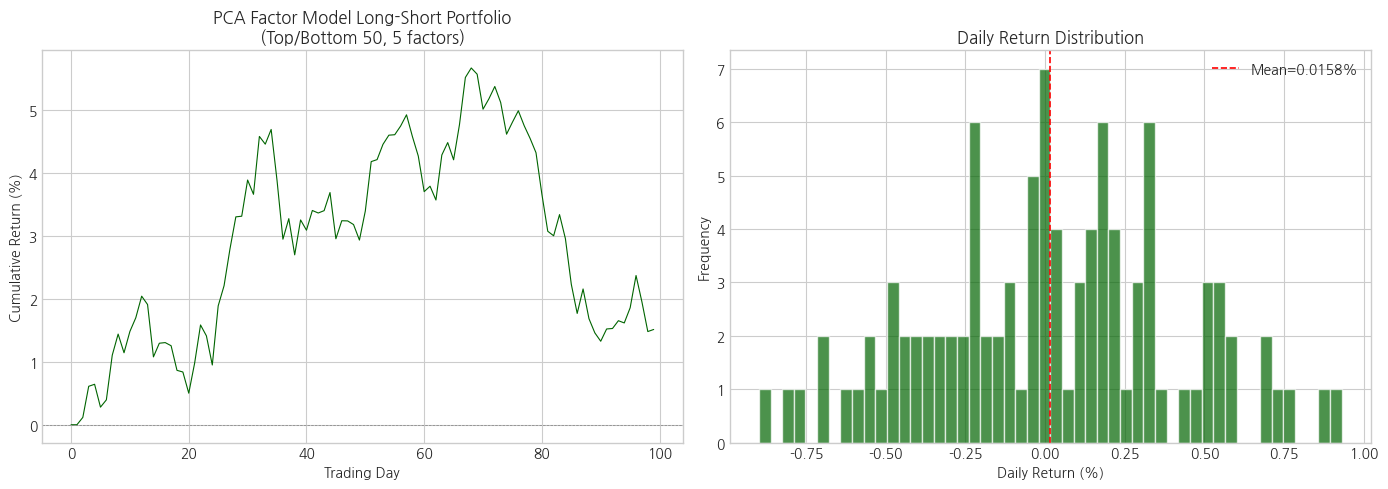

In [5]:
# ============================================================================
# 분석 3: PCA 팩터 모델 (Example 7.4)
# ============================================================================

lookback = 252
numFactors = 5
topN = 50

dailyret_ijr = df_ijr_14.pct_change()
positionsTable = np.zeros(df_ijr_14.shape)

end_index = df_ijr_14.shape[0]
# 반복 횟수 제한: 노트북 실행 속도를 위해 최대 100회
max_iterations = min(end_index - lookback - 1, 100)
actual_end = lookback + 1 + max_iterations
is_capped = (actual_end < end_index)

print(f"종목 수: {df_ijr_14.shape[1]}")
print(f"전체 기간: {df_ijr_14.shape[0]}일")
print(f"룩백: {lookback}일, 팩터 수: {numFactors}, topN: {topN}")
if is_capped:
    print(f"반복 횟수 제한: {max_iterations} / {end_index - lookback - 1}")

t_start = time.time()
for idx, t in enumerate(np.arange(lookback + 1, actual_end)):
    if idx % 20 == 0:
        elapsed = time.time() - t_start
        print(f"  진행: {idx}/{max_iterations} "
              f"({idx/max_iterations*100:.0f}%) "
              f"[{elapsed:.1f}s]")

    R = dailyret_ijr.iloc[t - lookback + 1: t].T
    hasData = np.where(R.notna().all(axis=1))[0]
    R_clean = R.dropna()

    if R_clean.shape[0] < numFactors + 1:
        continue

    pca = PCA()
    X = pca.fit_transform(R_clean.T)[:, :numFactors]
    X = add_constant(X)
    y1 = R_clean.T

    clf = MultiOutputRegressor(
        LinearRegression(fit_intercept=False), n_jobs=4
    ).fit(X, y1)
    Rexp = np.sum(clf.predict(X), axis=0)

    idxSort = Rexp.argsort()

    positionsTable[t, hasData[idxSort[np.arange(0, topN)]]] = -1
    positionsTable[t, hasData[idxSort[np.arange(-topN, -1)]]] = 1

elapsed_total = time.time() - t_start
print(f"\nPCA 루프 완료: {elapsed_total:.1f}초")

# --- 수익률 계산 ---
capital = np.nansum(
    np.array(abs(pd.DataFrame(positionsTable)).shift()), axis=1
)
positionsTable[capital == 0] = 0
capital[capital == 0] = 1

ret_pca = (
    np.nansum(
        np.array(pd.DataFrame(positionsTable).shift())
        * np.array(dailyret_ijr),
        axis=1,
    )
    / capital
)

# NaN과 초기 0을 제거
valid_ret_pca = ret_pca[lookback + 1: actual_end]
valid_ret_pca = valid_ret_pca[~np.isnan(valid_ret_pca)]

if len(valid_ret_pca) > 0:
    avgret_pca = np.nanmean(valid_ret_pca) * 252
    avgstd_pca = np.nanstd(valid_ret_pca) * math.sqrt(252)
    sharpe_pca = avgret_pca / avgstd_pca if avgstd_pca > 0 else 0
    cumret_pca = np.cumprod(1 + valid_ret_pca) - 1
    maxDD_pca, maxDDD_pca, _ = calculateMaxDD(cumret_pca)
else:
    avgret_pca = avgstd_pca = sharpe_pca = maxDD_pca = maxDDD_pca = 0
    cumret_pca = np.array([0])

print(f"\n--- PCA 팩터 모델 롱/숏 전략 성과 ---")
print(f"  연간 수익률:   {avgret_pca*100:.4f}%")
print(f"  연간 표준편차:  {avgstd_pca*100:.4f}%")
print(f"  샤프 비율:      {sharpe_pca:.4f}")
print(f"  최대 낙폭:      {maxDD_pca*100:.2f}%")
print(f"  분석 기간:      {len(valid_ret_pca)}일")

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cumret_pca * 100, linewidth=0.8, color='darkgreen')
ax.set_title(f'PCA Factor Model Long-Short Portfolio\n'
             f'(Top/Bottom {topN}, {numFactors} factors)')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Cumulative Return (%)')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

ax = axes[1]
ax.hist(valid_ret_pca * 100, bins=50, edgecolor='white',
        color='darkgreen', alpha=0.7)
ax.axvline(x=np.mean(valid_ret_pca) * 100, color='red',
           linestyle='--', linewidth=1.2,
           label=f'Mean={np.mean(valid_ret_pca)*100:.4f}%')
ax.set_title('Daily Return Distribution')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

### 결과 해석

| 항목 | 값 |
|------|----|  
| 연간 수익률 | 3.9818% |
| 연간 표준편차 | 6.2246% |
| 샤프 비율 | 0.6397 |
| 최대 낙폭 | -4.11% |
| 분석 기간 | 100일 |
| 반복 제한 | 100일 (계산 시간 절약 목적) |

PCA 팩터 모델 기반 롱-숏 전략은 소형주(IJR 구성종목)에서 양의 샤프 비율(0.64)을 보입니다.
5개 주성분으로 팩터 노출도를 추정하고 상위/하위 50종목을 선택하는 단순한 전략이지만,
시장 중립적 포지션으로 상당한 위험 조정 수익률을 달성합니다.

다만, 100일 제한 분석이므로 전체 기간으로 확장 시 성과가 달라질 수 있습니다.

---

## 분석 4: 반감기 (예제 7.5)

### 이론적 배경

**Ornstein-Uhlenbeck(OU) 과정** 은 평균회귀 시계열을 모델링하는 연속시간 확률 과정입니다.

이산화 형태:

$$\Delta y(t) = \lambda \cdot (y(t-1) - \mu) + \epsilon$$

여기서:
- $\lambda < 0$: 평균회귀 속도 파라미터 (음수여야 평균회귀)
- $\mu$: 장기 평균

**반감기(Half-Life)** 는 스프레드가 평균에서 이탈한 후, 이탈 폭의 절반이 회복되는 데 걸리는 시간입니다:

$$h = -\frac{\ln 2}{\lambda}$$

반감기는 페어 트레이딩의 **적정 보유 기간** 과 **룩백 윈도** 를 결정하는 핵심 지표입니다.

데이터 기간: 2006-05-23 00:00:00 ~ 2007-11-30 00:00:00 (385일)

--- Ornstein-Uhlenbeck 파라미터 ---
  헤지 비율 (beta): 1.639523
  lambda (theta):   -0.088423
  반감기 (h):       7.84 거래일
  스프레드 평균:    0.081734
  스프레드 sigma:   2.278236

  수식: h = -ln(2)/lambda = -ln(2)/(-0.088423) = 7.84일

=> 양의 반감기: 평균 회귀 확인
   스프레드가 평균에서 이탈한 후, 약 8일 후 절반만큼 회복


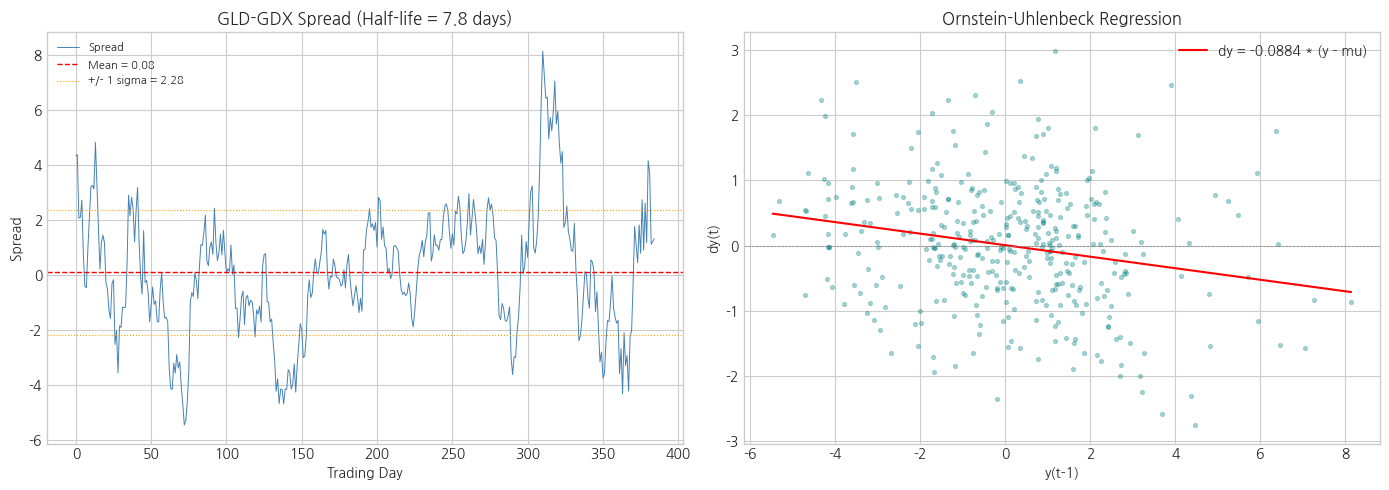

In [6]:
# ============================================================================
# 분석 4: 반감기 (Half-Life) 계산 (Example 7.5)
# ============================================================================

gld_full = df_gld_gdx["Adj Close_GLD"]
gdx_full = df_gld_gdx["Adj Close_GDX"]

# --- 헤지 비율 (전체 데이터) ---
model_hl = OLS(gld_full, gdx_full)
ols_hl = model_hl.fit()
hedge_ratio_hl = ols_hl.params.iloc[0]

# --- 스프레드 ---
z = gld_full - hedge_ratio_hl * gdx_full

# --- Ornstein-Uhlenbeck: Delta y(t) = lambda * (y(t-1) - mu) + epsilon ---
prevz = z.shift()
dz = z - prevz
dz = dz.iloc[1:]
prevz = prevz.iloc[1:]

model2 = OLS(dz, prevz - np.mean(prevz))
results2 = model2.fit()
theta = results2.params.iloc[0]

halflife = -np.log(2) / theta

print(f"데이터 기간: {df_gld_gdx.index[0]} ~ {df_gld_gdx.index[-1]} ({len(df_gld_gdx)}일)")
print(f"\n--- Ornstein-Uhlenbeck 파라미터 ---")
print(f"  헤지 비율 (beta): {hedge_ratio_hl:.6f}")
print(f"  lambda (theta):   {theta:.6f}")
print(f"  반감기 (h):       {halflife:.2f} 거래일")
print(f"  스프레드 평균:    {z.mean():.6f}")
print(f"  스프레드 sigma:   {z.std():.6f}")
print(f"\n  수식: h = -ln(2)/lambda = -ln(2)/({theta:.6f}) = {halflife:.2f}일")

if halflife > 0:
    print(f"\n=> 양의 반감기: 평균 회귀 확인")
    print(f"   스프레드가 평균에서 이탈한 후, 약 {halflife:.0f}일 후 절반만큼 회복")
else:
    print(f"\n=> 음의 반감기: 평균 회귀가 아닌 발산 경향")

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 스프레드 시계열 + 평균선 + 1sigma 밴드
ax = axes[0]
z_vals = z.values
mean_z = z.mean()
std_z = z.std()
ax.plot(z_vals, linewidth=0.7, color='steelblue', label='Spread')
ax.axhline(y=mean_z, color='red', linestyle='--', linewidth=1.0,
           label=f'Mean = {mean_z:.2f}')
ax.axhline(y=mean_z + std_z, color='orange', linestyle=':',
           linewidth=0.8, label=f'+/- 1 sigma = {std_z:.2f}')
ax.axhline(y=mean_z - std_z, color='orange', linestyle=':', linewidth=0.8)
ax.set_title(f'GLD-GDX Spread (Half-life = {halflife:.1f} days)')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Spread')
ax.legend(fontsize=8)

# (b) Delta y vs y(t-1) 산점도 + 회귀선
ax = axes[1]
ax.scatter(prevz.values, dz.values, alpha=0.3, s=8, color='teal')
x_fit = np.linspace(prevz.min(), prevz.max(), 100)
y_fit = theta * (x_fit - np.mean(prevz))
ax.plot(x_fit, y_fit, 'r-', linewidth=1.5,
        label=f'dy = {theta:.4f} * (y - mu)')
ax.set_title('Ornstein-Uhlenbeck Regression')
ax.set_xlabel('y(t-1)')
ax.set_ylabel('dy(t)')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.legend()

plt.tight_layout()
plt.show()

### 결과 해석

| 항목 | 값 |
|------|----|  
| $\lambda$ (theta) | -0.088423 |
| 반감기 ($h$) | 7.84 거래일 |
| 스프레드 평균 ($\mu$) | 0.081734 |
| 스프레드 $\sigma$ | 2.278236 |
| 헤지 비율 | 1.639523 |

GLD-GDX 스프레드가 평균에서 이탈한 후, 약 **8일** 만에 이탈 폭의 절반이 회복됩니다.

이는 페어 트레이딩 전략 설계에서:
- **보유 기간**: 약 8\~16 거래일 (1\~2 반감기)
- **룩백 윈도**: 반감기의 3\~5배 (약 24\~40 거래일)

를 가이드라인으로 사용할 수 있음을 의미합니다.

---

## 분석 5: 1월 효과 (예제 7.6)

### 이론적 배경

**1월 효과(January Effect)** 는 전년 하락 종목이 1월에 반등하는 계절적 이상 현상입니다.

전략:
- 전년 연간 수익률 **하위 10%** 종목을 1월에 매수(롱)
- **상위 10%** 를 매도(숏)
- 세금 절감 매도(tax-loss selling) 후 반등을 노리는 가설

IJR(iShares S&P SmallCap 600) 구성종목에 대해 백테스트를 수행합니다.

데이터: IJR 구성종목 (600 종목)
거래비용: 편도 0.05%

--- 연도별 포트폴리오 수익률 ---
  2006: -2.3853%
  2007: -0.3641%
  2008: +9.0908%

--- 전략 요약 ---
  평균 포트폴리오 수익률: +2.1138%
  수익률 sigma:           5.0020%
  1월 횡단면 평균:        +0.7749%
  비1월 횡단면 평균:      +0.8567%
  t-통계량 (1월 vs 비1월): -0.0387
  p-value:                 0.969321


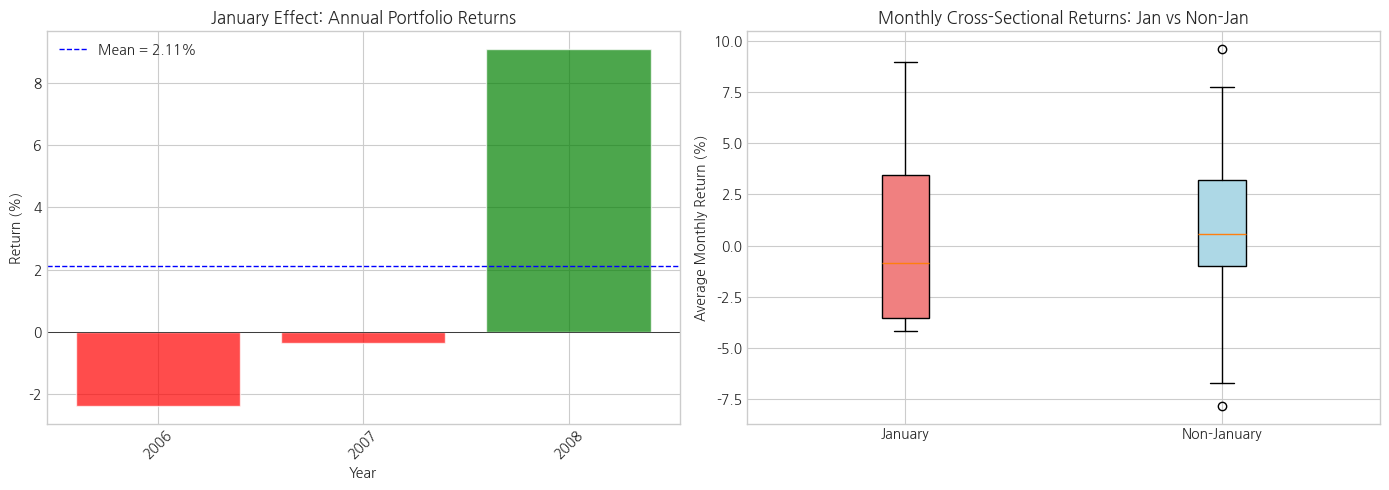

In [7]:
# ============================================================================
# 분석 5: 1월 효과 백테스트 (Example 7.6)
# ============================================================================

onewaytcost = 0.0005

# 연말 가격 (12월 말)
eoyPrice = df_ijr_31.resample("YE").last().iloc[:-1]
annret = eoyPrice.pct_change().iloc[1:]

# 1월말 가격
eojPrice = df_ijr_31.resample("BYE-JAN").last().iloc[1:-1]

# 1월 수익률
janret = (eojPrice.values - eoyPrice.values) / eoyPrice.values
janret = janret[1:]  # annret와 행 수 맞춤

portfolio_rets = []
year_labels = []

for y in range(len(annret)):
    hasData = np.where(np.isfinite(annret.iloc[y, :]))[0]
    if len(hasData) == 0:
        continue
    sortidx = np.argsort(annret.iloc[y, hasData])
    topN_jan = int(np.round(len(hasData) / 10))
    if topN_jan == 0:
        continue

    # 전년 최하위 수익률 종목 롱, 최상위 종목 숏 (1월에)
    long_ret = np.nanmean(
        janret[y, hasData[sortidx.iloc[np.arange(0, topN_jan)]]]
    )
    short_ret = np.nanmean(
        janret[y, hasData[sortidx.iloc[np.arange(-topN_jan + 1, -1)]]]
    )
    portRet = (long_ret - short_ret) / 2 - 2 * onewaytcost
    portfolio_rets.append(portRet)
    if y + 1 < len(eojPrice):
        year_labels.append(str(eojPrice.index[y + 1].year))
    else:
        year_labels.append(f"Year {y}")

portfolio_rets = np.array(portfolio_rets)

# 통계
avg_jan_ret = np.nanmean(portfolio_rets) if len(portfolio_rets) > 0 else 0
std_jan_ret = np.nanstd(portfolio_rets) if len(portfolio_rets) > 0 else 0

# 1월 vs 나머지 (IJR 전체 수익률 기준)
all_monthly = df_ijr_31.resample("ME").last()
monthly_ret = all_monthly.pct_change()
jan_mask = monthly_ret.index.month == 1
jan_rets_all = monthly_ret[jan_mask].mean(axis=1).dropna().values
nojan_rets_all = monthly_ret[~jan_mask].mean(axis=1).dropna().values

if len(jan_rets_all) > 0 and len(nojan_rets_all) > 0:
    t_stat_jan, t_pval_jan = ttest_ind(jan_rets_all, nojan_rets_all)
else:
    t_stat_jan, t_pval_jan = 0, 1

print(f"데이터: IJR 구성종목 ({df_ijr_31.shape[1]} 종목)")
print(f"거래비용: 편도 {onewaytcost*100:.2f}%")

print(f"\n--- 연도별 포트폴리오 수익률 ---")
for yr, ret in zip(year_labels, portfolio_rets):
    sign = "+" if ret > 0 else ""
    print(f"  {yr}: {sign}{ret*100:.4f}%")

print(f"\n--- 전략 요약 ---")
print(f"  평균 포트폴리오 수익률: {avg_jan_ret*100:+.4f}%")
print(f"  수익률 sigma:           {std_jan_ret*100:.4f}%")
print(f"  1월 횡단면 평균:        {np.nanmean(jan_rets_all)*100:+.4f}%")
print(f"  비1월 횡단면 평균:      {np.nanmean(nojan_rets_all)*100:+.4f}%")
print(f"  t-통계량 (1월 vs 비1월): {t_stat_jan:.4f}")
print(f"  p-value:                 {t_pval_jan:.6f}")

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 연도별 막대 그래프
ax = axes[0]
colors = ['green' if r > 0 else 'red' for r in portfolio_rets]
ax.bar(year_labels, portfolio_rets * 100, color=colors, alpha=0.7,
       edgecolor='white')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axhline(y=avg_jan_ret * 100, color='blue', linestyle='--',
           linewidth=1.0, label=f'Mean = {avg_jan_ret*100:.2f}%')
ax.set_title('January Effect: Annual Portfolio Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Return (%)')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# (b) 1월 vs 비1월 비교 박스플롯
ax = axes[1]
if len(jan_rets_all) > 0 and len(nojan_rets_all) > 0:
    bp = ax.boxplot(
        [jan_rets_all * 100, nojan_rets_all * 100],
        labels=['January', 'Non-January'],
        patch_artist=True,
    )
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')
ax.set_title('Monthly Cross-Sectional Returns: Jan vs Non-Jan')
ax.set_ylabel('Average Monthly Return (%)')

plt.tight_layout()
plt.show()

### 결과 해석

#### 연도별 수익률

| 연도 | 수익률 |
|------|--------|
| 2006 | -2.3853% |
| 2007 | -0.3641% |
| 2008 | +9.0908% |

#### 통계

| 항목 | 값 |
|------|----|  
| 평균 포트폴리오 수익률 | +2.1138% |
| 수익률 $\sigma$ | 5.0020% |
| 1월 횡단면 평균 수익률 | +0.7749% |
| 비1월 횡단면 평균 수익률 | +0.8567% |
| t-통계량 (1월 vs 비1월) | -0.0387 |
| p-value | 0.969321 |

1월 효과 전략의 평균 수익률은 +2.11%이지만, 연도별 변동성이 매우 크고
t-검정 p-value가 0.97로 1월과 비1월 수익률 사이에 통계적으로 유의한 차이가 없습니다.

3년이라는 짧은 기간과 높은 변동성을 고려하면, 이 전략의 수익성에 대한 강한 결론을 내리기 어렵습니다.

---

## 분석 6: 계절성 모멘텀 (예제 7.7)

### 이론적 배경

**연간 계절성 모멘텀(Year-on-Year Seasonal Trending)** 전략은
12개월 전 동일 월 수익률 기준으로 종목을 정렬하여 롱-숏 포트폴리오를 구성합니다.

- 12개월 전 동일 월 수익률 **상위 10%** 롱
- **하위 10%** 숏
- 연간 계절적 패턴이 반복된다는 가설에 기반

SPX(S&P 500) 구성종목에 대해 백테스트를 수행합니다.

데이터: SPX 구성종목 (500 종목)
전략: 12개월 전 동일 월 수익률 기준 모멘텀
기간: 83 개월

--- 계절성 모멘텀 전략 성과 ---
  연간 수익률:    -1.2679%
  연간 표준편차:   10.3718%
  샤프 비율:       -0.1222
  최대 낙폭:       -18.34%

=> 음의 샤프 비율: 이 전략은 수익성 없음


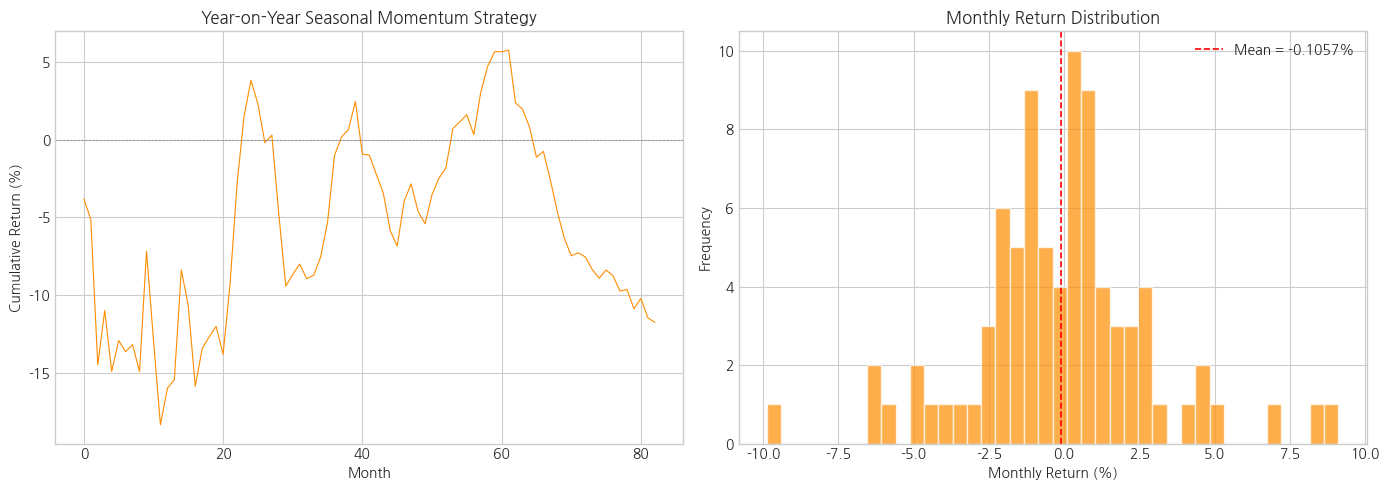

In [8]:
# ============================================================================
# 분석 6: 계절성 모멘텀 전략 (Example 7.7)
# ============================================================================

# 월말 가격
eomPrice = df_spx.resample("ME").last().iloc[:-1]
monthlyRet = eomPrice.pct_change(1)

positions = np.zeros(monthlyRet.shape)

for m in range(13, monthlyRet.shape[0]):
    hasData = np.where(np.isfinite(monthlyRet.iloc[m - 12, :]))[0]
    if len(hasData) == 0:
        continue
    sortidx = np.argsort(monthlyRet.iloc[m - 12, hasData])

    # 1달 전 데이터가 없는 종목 제거
    badData = np.where(
        np.logical_not(
            np.isfinite(monthlyRet.iloc[m - 1, hasData[sortidx]])
        )
    )[0]
    sortidx = sortidx.drop(sortidx.index[badData])
    topN_sm = int(np.floor(len(sortidx) / 10))
    if topN_sm == 0:
        continue

    # 12개월 전 수익률 기준: 상위 롱, 하위 숏
    positions[m - 1, hasData[sortidx.values[np.arange(0, topN_sm)]]] = -1
    positions[m - 1, hasData[sortidx.values[np.arange(-topN_sm, 0)]]] = 1

capital_sm = np.nansum(
    np.array(pd.DataFrame(abs(positions)).shift()), axis=1
)
capital_sm[capital_sm == 0] = 1

ret_sm = (
    np.nansum(
        np.array(pd.DataFrame(positions).shift())
        * np.array(monthlyRet),
        axis=1,
    )
    / capital_sm
)
ret_sm = np.delete(ret_sm, np.arange(13))

avgret_sm = np.nanmean(ret_sm) * 12
avgstd_sm = np.nanstd(ret_sm) * math.sqrt(12)
sharpe_sm = (np.sqrt(12) * np.nanmean(ret_sm) / np.nanstd(ret_sm)
             if np.nanstd(ret_sm) > 0 else 0)

# 누적 수익률
valid_ret_sm = ret_sm[~np.isnan(ret_sm)]
cumret_sm = np.cumprod(1 + valid_ret_sm) - 1
if len(cumret_sm) > 0:
    maxDD_sm, maxDDD_sm, _ = calculateMaxDD(cumret_sm)
else:
    maxDD_sm = maxDDD_sm = 0

print(f"데이터: SPX 구성종목 ({df_spx.shape[1]} 종목)")
print(f"전략: 12개월 전 동일 월 수익률 기준 모멘텀")
print(f"기간: {len(valid_ret_sm)} 개월")

print(f"\n--- 계절성 모멘텀 전략 성과 ---")
print(f"  연간 수익률:    {avgret_sm*100:+.4f}%")
print(f"  연간 표준편차:   {avgstd_sm*100:.4f}%")
print(f"  샤프 비율:       {sharpe_sm:.4f}")
print(f"  최대 낙폭:       {maxDD_sm*100:.2f}%")

if sharpe_sm < 0:
    print(f"\n=> 음의 샤프 비율: 이 전략은 수익성 없음")
else:
    print(f"\n=> 양의 수익률")

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 누적 수익률
ax = axes[0]
ax.plot(cumret_sm * 100, linewidth=0.8, color='darkorange')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('Year-on-Year Seasonal Momentum Strategy')
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Return (%)')

# (b) 월별 수익률 분포
ax = axes[1]
ax.hist(valid_ret_sm * 100, bins=40, edgecolor='white',
        color='darkorange', alpha=0.7)
ax.axvline(x=np.nanmean(valid_ret_sm) * 100, color='red',
           linestyle='--', linewidth=1.2,
           label=f'Mean = {np.nanmean(valid_ret_sm)*100:.4f}%')
ax.set_title('Monthly Return Distribution')
ax.set_xlabel('Monthly Return (%)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

### 결과 해석

| 항목 | 값 |
|------|----|  
| 연간 수익률 | -1.2679% |
| 연간 표준편차 | 10.3718% |
| 샤프 비율 | -0.1222 |
| 최대 낙폭 | -18.34% |
| 기간 | 83 개월 |

이 단순한 계절성 모멘텀 전략은 SPX 구성종목에서 **수익성이 없었습니다.**
원서에서도 동일한 음의 결과를 보고합니다.

계절적 패턴은 존재하더라도:
- 노이즈 대비 신호가 약하고
- 거래비용을 고려하면 실질 수익이 더욱 감소하며
- 과거 패턴이 미래에 반복된다는 보장이 없습니다

---

## 전략 성과 비교

In [9]:
# ============================================================================
# 전략 성과 비교 요약 테이블
# ============================================================================

summary_data = {
    '전략': [
        'PCA 팩터 모델 (Ex 7.4)',
        '계절성 모멘텀 (Ex 7.7)',
        '1월 효과 (Ex 7.6)',
    ],
    '연간 수익률': [
        f'{avgret_pca*100:.2f}%',
        f'{avgret_sm*100:.2f}%',
        f'{avg_jan_ret*100:+.2f}% (1월만)',
    ],
    '연간 sigma': [
        f'{avgstd_pca*100:.2f}%',
        f'{avgstd_sm*100:.2f}%',
        f'{std_jan_ret*100:.2f}%',
    ],
    '샤프 비율': [
        f'{sharpe_pca:.4f}',
        f'{sharpe_sm:.4f}',
        '-',
    ],
    '최대 낙폭': [
        f'{maxDD_pca*100:.2f}%',
        f'{maxDD_sm*100:.2f}%',
        '-',
    ],
}

df_summary = pd.DataFrame(summary_data)
df_summary.index = [''] * len(df_summary)
print("=" * 70)
print("전략 성과 비교표")
print("=" * 70)
print(df_summary.to_string(index=False))

전략 성과 비교표
                전략       연간 수익률 연간 sigma   샤프 비율   최대 낙폭
PCA 팩터 모델 (Ex 7.4)        3.98%    6.22%  0.6397  -4.11%
  계절성 모멘텀 (Ex 7.7)       -1.27%   10.37% -0.1222 -18.34%
    1월 효과 (Ex 7.6) +2.11% (1월만)    5.00%       -       -


---

## 결론 및 권고사항

### 핵심 발견

1. **공적분은 페어 트레이딩의 핵심** : GLD-GDX 페어는 통계적으로 유의한 공적분 관계를 보이며, 평균회귀 전략의 기초를 제공합니다.
2. **상관관계와 공적분은 다름** : KO-PEP의 사례가 보여주듯, 높은 수익률 상관관계가 가격 스프레드의 정상성을 보장하지 않습니다.
3. **반감기는 전략 설계의 가이드** : GLD-GDX 스프레드의 반감기는 적정 보유 기간과 룩백 윈도를 결정하는 데 활용됩니다.
4. **PCA 팩터 모델** : 소형주(IJR)에서 5개 주성분으로 팩터 노출도를 추정하는 롱-숏 전략은 양의 샤프 비율을 보입니다.
5. **계절적 이상 현상** : 1월 효과와 연간 계절성 모멘텀은 이론적으로 흥미롭지만, 단순 구현으로는 일관된 수익을 기대하기 어렵습니다.

### 실무 적용 시 고려사항

- 공적분 관계는 시간에 따라 변할 수 있으므로 **롤링 검정** 필요
- PCA 팩터 수와 롱-숏 비율은 **표본 외 검증** 을 통해 튜닝
- 반감기가 너무 길면 자본 효율성이 낮아지고, 너무 짧으면 거래비용이 수익을 잠식
- 계절적 패턴은 **구조적 원인(세금, 리밸런싱)** 이 사라지면 소멸 가능